<a href="https://colab.research.google.com/github/sreenandinisreenivasan3-sree/ML-project/blob/main/Day_9_Activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [192]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [193]:
data=pd.read_csv('/content/the_loan.csv')
data.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [194]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [195]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [196]:
data.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [197]:
data.shape

(614, 13)

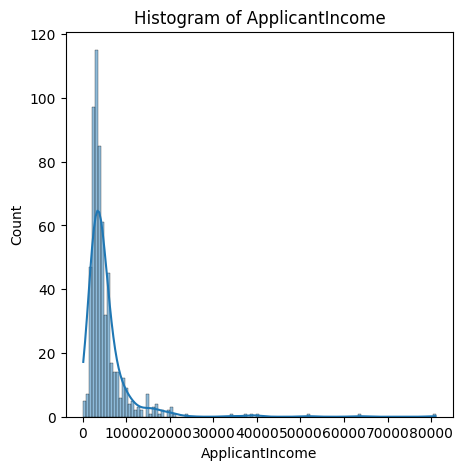

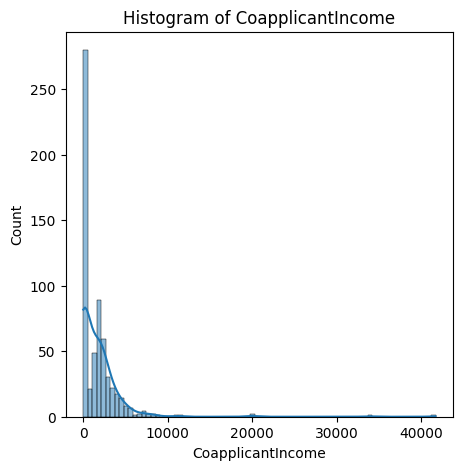

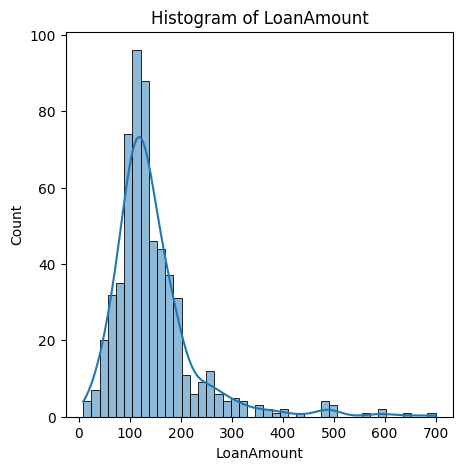

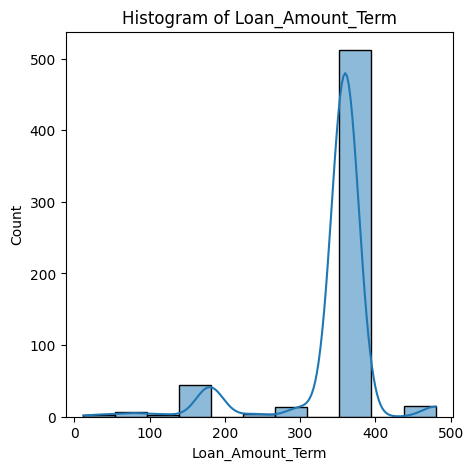

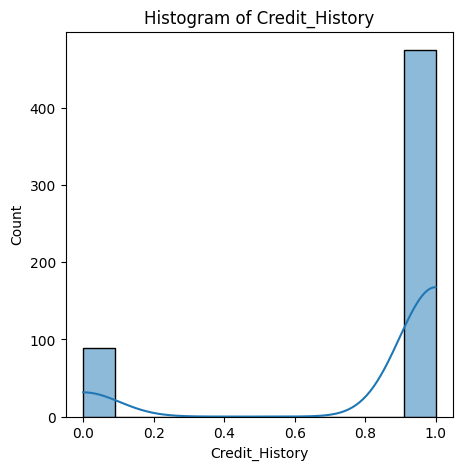

In [198]:
numeric_cols=data.select_dtypes(include=np.number).columns
for col in numeric_cols:
  plt.figure(figsize=(5,5))
  sns.histplot(data[col],kde=True)
  plt.title(f'Histogram of {col}')
  plt.show()

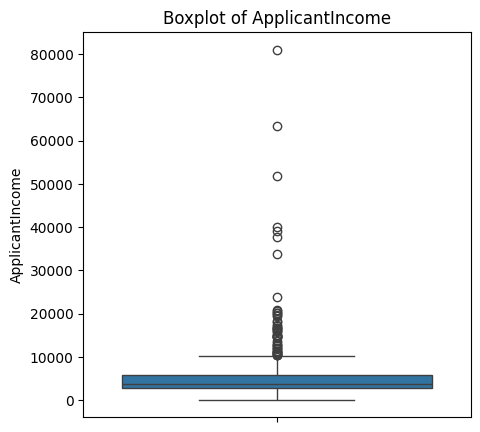

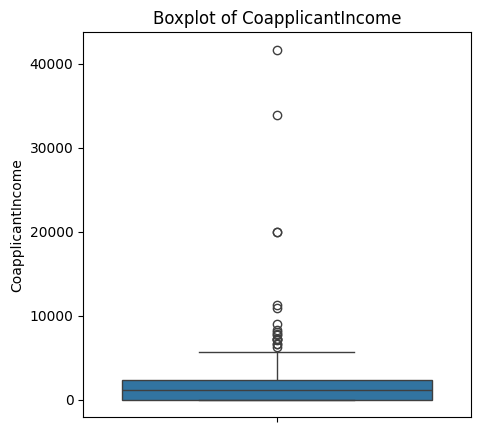

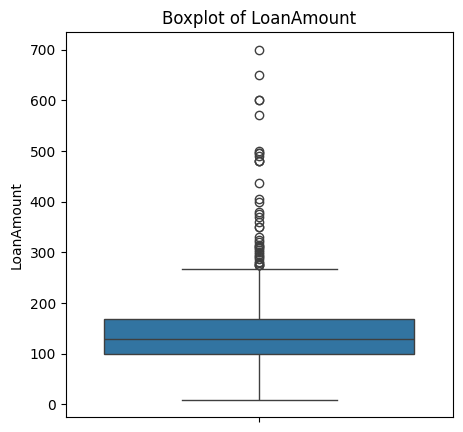

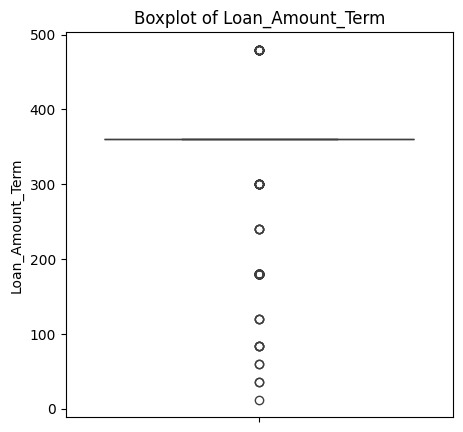

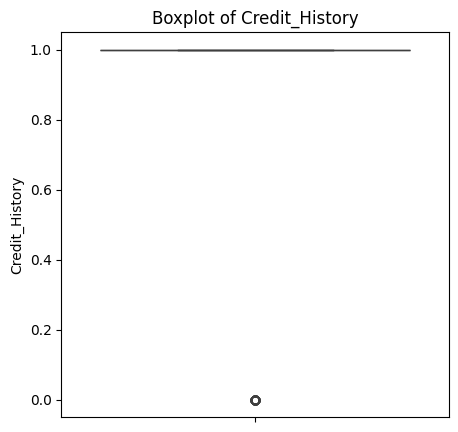

In [199]:
num_cols=data.select_dtypes(include=np.number).columns
for col in num_cols:
  plt.figure(figsize=(5,5))
  sns.boxplot(y=data[col])
  plt.title(f'Boxplot of {col}')
  plt.show()

In [200]:
data=data.drop(['Loan_ID'],axis=1)

In [201]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [202]:
data.dropna(subset=['Married','Dependents'], inplace=True)

In [203]:
data.isnull().sum()

,0
Gender,13
Married,0
Dependents,0
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,20
Loan_Amount_Term,13
Credit_History,50


In [204]:
self_emplo_mode = data['Self_Employed'].mode()[0]
data['Self_Employed'].fillna(self_emplo_mode, inplace=True)

/tmp/ipykernel_334/2408364781.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Self_Employed'].fillna(self_emplo_mode, inplace=True)


In [205]:
cre_mode = data['Credit_History'].mode()[0]
data['Credit_History'].fillna(cre_mode, inplace=True)

/tmp/ipykernel_334/3109389705.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Credit_History'].fillna(cre_mode, inplace=True)


In [206]:
amount_median = data['LoanAmount'].median()
data['LoanAmount'].fillna(amount_median, inplace=True)

term_median = data['Loan_Amount_Term'].median()
data['Loan_Amount_Term'].fillna(term_median, inplace=True)
data[['LoanAmount', 'Loan_Amount_Term','Credit_History','Self_Employed']].isnull().sum()

/tmp/ipykernel_334/3917587583.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['LoanAmount'].fillna(amount_median, inplace=True)
/tmp/ipykernel_334/3917587583.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0
Self_Employed,0


In [207]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])
data['Loan_Status'] = le.fit_transform(data['Loan_Status'])
data['Married']=le.fit_transform(data['Married'])
data['Education']=le.fit_transform(data['Education'])
data['Self_Employed']=le.fit_transform(data['Self_Employed'])

<Axes: >

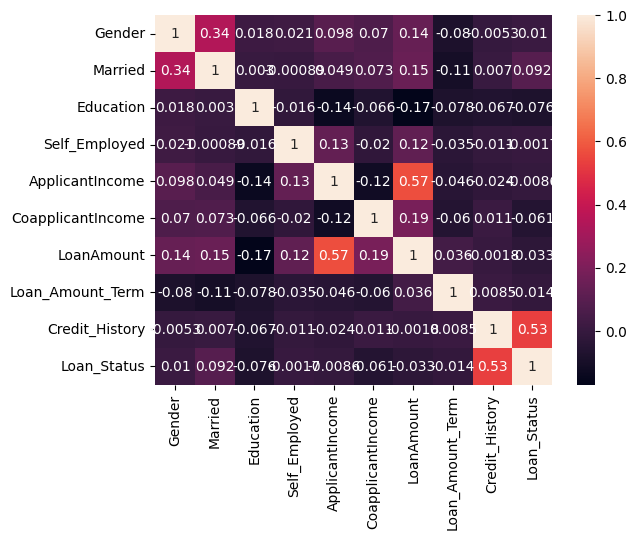

In [208]:
data.corr(numeric_only=True)
sns.heatmap(data.corr(numeric_only=True),annot=True)

In [209]:
data=pd.get_dummies(data,columns=['Dependents','Property_Area'],drop_first=True,dtype=int)

In [210]:
data.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,5849,0.0,128.0,360.0,1.0,1,0,0,0,0,1
1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,1,0,0,0,0
2,1,1,0,1,3000,0.0,66.0,360.0,1.0,1,0,0,0,0,1
3,1,1,1,0,2583,2358.0,120.0,360.0,1.0,1,0,0,0,0,1
4,1,0,0,0,6000,0.0,141.0,360.0,1.0,1,0,0,0,0,1


In [216]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data['LoanAmount'] = scaler.fit_transform(data[['LoanAmount']])
data['Loan_Amount_Term'] = scaler.fit_transform(data[['Loan_Amount_Term']])

In [217]:
X = data.drop(['Loan_Status'], axis=1)
y = data['Loan_Status']

In [219]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [220]:
from sklearn.linear_model import LogisticRegression
logi_reg_model = LogisticRegression(random_state=42)
logi_reg_model.fit(X_train, y_train)
y_pred_logi_reg = logi_reg_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log_reg))

Logistic Regression Accuracy: 0.9750

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        41
           1       0.96      1.00      0.98        79

    accuracy                           0.97       120
   macro avg       0.98      0.96      0.97       120
weighted avg       0.98      0.97      0.97       120



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [221]:
from sklearn.tree import DecisionTreeClassifier

dtc_model = DecisionTreeClassifier(random_state=42)
dtc_model.fit(X_train, y_train)
y_pred_dtc = dtc_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
accuracy_dtc = accuracy_score(y_test, y_pred_dtc)
print(f"Decision Tree Classifier Accuracy: {accuracy_dtc:.4f}")
print("\nDecision Tree Classifier Classification Report:")
print(classification_report(y_test, y_pred_dtc))

Decision Tree Classifier Accuracy: 0.7250

Decision Tree Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.56      0.58        41
           1       0.78      0.81      0.80        79

    accuracy                           0.72       120
   macro avg       0.69      0.69      0.69       120
weighted avg       0.72      0.72      0.72       120



In [222]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Classifier Accuracy: {accuracy_rf:.4f}")
print("\nRandom Forest Classifier Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier Accuracy: 0.7833

Random Forest Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.49      0.61        41
           1       0.78      0.94      0.85        79

    accuracy                           0.78       120
   macro avg       0.79      0.71      0.73       120
weighted avg       0.79      0.78      0.77       120

